In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print(df.head())
print(df.shape)
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [2]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [3]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


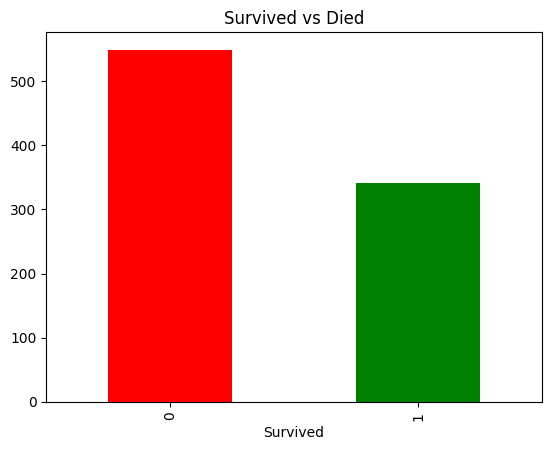

In [5]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Survived vs Died')
plt.show()

In [6]:
print(df.groupby('Sex')['Survived'].value_counts())

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


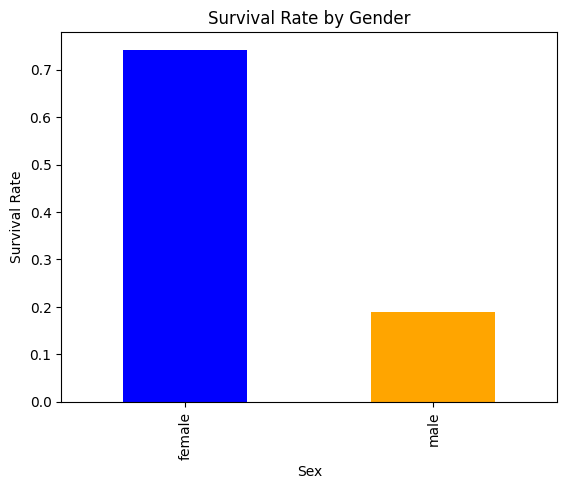

In [7]:
import matplotlib.pyplot as plt

df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['blue','orange'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

In [12]:

print(df.groupby('Pclass')['Survived'].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


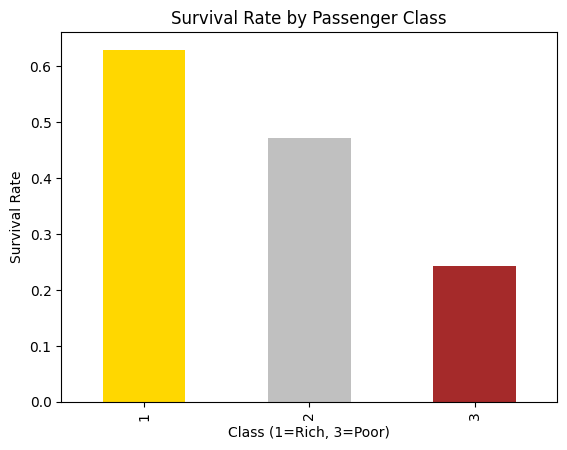

In [13]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold','silver','brown'])
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Class (1=Rich, 3=Poor)')
plt.show()

In [14]:

df_model = df[['Survived', 'Pclass', 'Sex', 'Age']].dropna()
df_model = df_model.copy()
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

print(df_model.head())
print(df_model.shape)

   Survived  Pclass  Sex   Age
0         0       3    0  22.0
1         1       1    1  38.0
2         1       3    1  26.0
3         1       1    1  35.0
4         0       3    0  35.0
(714, 4)


In [15]:
X = df_model[['Pclass', 'Sex', 'Age']]
y = df_model['Survived']

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (714, 3)
Output shape: (714,)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [17]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 77.62%


In [18]:
person = [[3, 0, 25]]
result = model.predict(person)

print("Survived!" if result[0] == 1 else "Did not survive 😢")

Did not survive 😢


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [19]:
person2 = [[1, 1, 25]]
result2 = model.predict(person2)
print("Survived!" if result2[0] == 1 else "Did not survive 😢")

Survived!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
